### Numpy basics

1\. Find the row, column and overall means for the following matrix:

```python
m = np.arange(12).reshape((3,4))
```

In [1]:
import numpy as np

In [2]:
m = np.arange(12).reshape((3,4))
print(m)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [3]:
rows_mean = [row.mean() for row in m]
print(rows_mean)

[np.float64(1.5), np.float64(5.5), np.float64(9.5)]


In [4]:
columns_mean = [row.mean() for row in m.T] 
print(m.T)
print(columns_mean)

[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
[np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]


In [5]:
# EASY WAY:
r = m.mean(axis=1)
c = m.mean(axis=0)
print(r,c)

[1.5 5.5 9.5] [4. 5. 6. 7.]


In [6]:
# Intuitively for the overall mean
o = m.mean()
print(o)

5.5


2\. Find the outer product of the following two vecotrs

```python
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])
```

Do this in the following ways:

   * Using the function outer in numpy
   * Using a nested for loop or list comprehension
   * Using numpy broadcasting operatoins


In [7]:
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])
print(u,v)

[1 3 5 7] [2 4 6 8]


In [8]:
# using the numpy function outer
np.outer(u,v) # this returns out[i, j] = u[i] * v[j]

array([[ 2,  4,  6,  8],
       [ 6, 12, 18, 24],
       [10, 20, 30, 40],
       [14, 28, 42, 56]])

In [9]:
# using a nested for loop

outer_product = [ u[i]*v[j] for i in range(4) for j in range(4) ]
outer_product = np.array(outer_product).reshape(4,4)
outer_product

array([[ 2,  4,  6,  8],
       [ 6, 12, 18, 24],
       [10, 20, 30, 40],
       [14, 28, 42, 56]])

In [10]:
# using numpy broadcasting operations
# it allows NumPy to perform arithmetic operations on arrays of different shapes as if they were the same shape,
# For that, Numpy virtually expands dimension so that they match the larger array's shape.

fail_broadcasting = u*v
fail_broadcasting

array([ 2, 12, 30, 56])

In [11]:
broadcasting = u[:, np.newaxis] * v # newaxis convierte u en un array (4,1) 
broadcasting

array([[ 2,  4,  6,  8],
       [ 6, 12, 18, 24],
       [10, 20, 30, 40],
       [14, 28, 42, 56]])

3\. Create a 10 by 6 matrix of random uniform numbers. Set all rows with any entry less than 0.1 to be zero

Hint: Use the following numpy functions - np.random.random, np.any as well as Boolean indexing and the axis argument.

In [12]:
import numpy.random as npr
npr.seed(123) 

# Create a 10 by 6 matrix of random uniform numbers.
a = npr.random(60) # random values from a uniform distrubtion in [0.0, 1.0) for a given shape
a = a.reshape(10,6)
print(a)

[[0.69646919 0.28613933 0.22685145 0.55131477 0.71946897 0.42310646]
 [0.9807642  0.68482974 0.4809319  0.39211752 0.34317802 0.72904971]
 [0.43857224 0.0596779  0.39804426 0.73799541 0.18249173 0.17545176]
 [0.53155137 0.53182759 0.63440096 0.84943179 0.72445532 0.61102351]
 [0.72244338 0.32295891 0.36178866 0.22826323 0.29371405 0.63097612]
 [0.09210494 0.43370117 0.43086276 0.4936851  0.42583029 0.31226122]
 [0.42635131 0.89338916 0.94416002 0.50183668 0.62395295 0.1156184 ]
 [0.31728548 0.41482621 0.86630916 0.25045537 0.48303426 0.98555979]
 [0.51948512 0.61289453 0.12062867 0.8263408  0.60306013 0.54506801]
 [0.34276383 0.30412079 0.41702221 0.68130077 0.87545684 0.51042234]]


In [13]:
# Set all rows with any entry less than 0.1 to be zero

mask = (a < 0.1)
print(mask)

[[False False False False False False]
 [False False False False False False]
 [False  True False False False False]
 [False False False False False False]
 [False False False False False False]
 [ True False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]]


In [14]:
mask_filas = np.any(mask, axis=1) # Si encuentra al menos un True en la fila, marca toda la fila como True.
#print(mask_filas) # esto tiene 10 valores, uno por cada fila porque usamos axis=1
a[mask_filas] = 0 # aplica para las filas con true
print(a)

[[0.69646919 0.28613933 0.22685145 0.55131477 0.71946897 0.42310646]
 [0.9807642  0.68482974 0.4809319  0.39211752 0.34317802 0.72904971]
 [0.         0.         0.         0.         0.         0.        ]
 [0.53155137 0.53182759 0.63440096 0.84943179 0.72445532 0.61102351]
 [0.72244338 0.32295891 0.36178866 0.22826323 0.29371405 0.63097612]
 [0.         0.         0.         0.         0.         0.        ]
 [0.42635131 0.89338916 0.94416002 0.50183668 0.62395295 0.1156184 ]
 [0.31728548 0.41482621 0.86630916 0.25045537 0.48303426 0.98555979]
 [0.51948512 0.61289453 0.12062867 0.8263408  0.60306013 0.54506801]
 [0.34276383 0.30412079 0.41702221 0.68130077 0.87545684 0.51042234]]


4\. Use np.linspace to create an array of 100 numbers between 0 and 2π (includsive).

  * Extract every 10th element using slice notation
  * Reverse the array using slice notation
  * Extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
  * Make a plot showing the sin and cos functions and indicate where they are close

In [15]:
# create an array of 100 numbers between 0 and 2π
x = np.linspace(0,2*np.pi,100)
#print(x)

In [16]:
# extract every 10th element using slice notation [inicio : fin : paso]
x_a = x[::10]
#print(x_a)

In [17]:
# reverse the array using slice notation
x_b = x[::-1]
#print(x_b)

In [18]:
# extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
#x_c = [element for element in x if abs(np.sin(element)-np.cos(element))<0.1]
x_c = x[np.abs(np.sin(x) - np.cos(x)) < 0.1]
print(x_c)

[0.76159822 0.82506474 3.87145761 3.93492413]


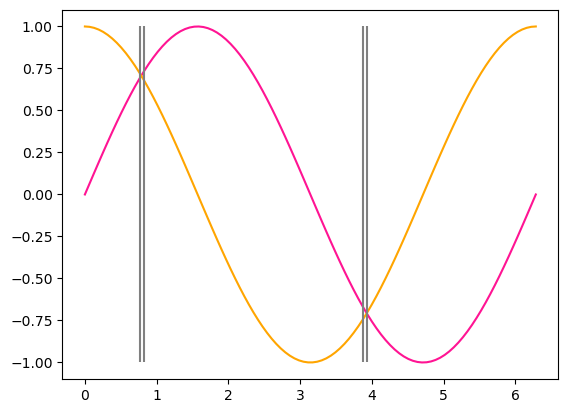

In [19]:
# make a plot showing the sin and cos functions and indicate where they are close

import matplotlib.pyplot as plt

plt.plot(x, np.sin(x), color='deeppink')
plt.plot(x, np.cos(x), color='orange')
plt.vlines(x_c, -1, 1, color='gray')

plt.show()

5\. Create a matrix that shows the 10 by 10 multiplication table.

 * Find the trace of the matrix
 * Extract the anto-diagonal (this should be ```array([10, 18, 24, 28, 30, 30, 28, 24, 18, 10])```)
 * Extract the diagnoal offset by 1 upwards (this should be ```array([ 2,  6, 12, 20, 30, 42, 56, 72, 90])```)

In [20]:
# Create a matrix that shows the 10 by 10 multiplication table.

u = np.array([[1,2,3,4,5,6,7,8,9,10]]) # shape 1,10
v =  np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]]) # shape 10.1
multiplication_table = u*v
multiplication_table 

array([[  1,   2,   3,   4,   5,   6,   7,   8,   9,  10],
       [  2,   4,   6,   8,  10,  12,  14,  16,  18,  20],
       [  3,   6,   9,  12,  15,  18,  21,  24,  27,  30],
       [  4,   8,  12,  16,  20,  24,  28,  32,  36,  40],
       [  5,  10,  15,  20,  25,  30,  35,  40,  45,  50],
       [  6,  12,  18,  24,  30,  36,  42,  48,  54,  60],
       [  7,  14,  21,  28,  35,  42,  49,  56,  63,  70],
       [  8,  16,  24,  32,  40,  48,  56,  64,  72,  80],
       [  9,  18,  27,  36,  45,  54,  63,  72,  81,  90],
       [ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100]])

In [21]:
# Find the trace of the matrix

trace_m = np.trace(multiplication_table)
trace_m

np.int64(385)

In [22]:
# Extract the anto-diagonal (this should be array([10, 18, 24, 28, 30, 30, 28, 24, 18, 10]))

m_volteada = np.fliplr(multiplication_table)
#m_volteada
a_diag = np.diag(m_volteada)
a_diag

array([10, 18, 24, 28, 30, 30, 28, 24, 18, 10])

In [23]:
# Extract the diagnoal offset by 1 upwards (this should be array([ 2,  6, 12, 20, 30, 42, 56, 72, 90]))
#a_diag_upwars = [multiplication_table[i, i+1] for i in range(9)]
a_diag_upward = np.diag(multiplication_table, k=1)
a_diag_upward

array([ 2,  6, 12, 20, 30, 42, 56, 72, 90])

6\. Use broadcasting to create a grid of distances

Route 66 crosses the following cities in the US: Chicago, Springfield, Saint-Louis, Tulsa, Oklahoma City, Amarillo, Santa Fe, Albuquerque, Flagstaff, Los Angeles
The corresponding positions in miles are: 0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448

  * Construct a 2D grid of distances among each city along Route 66
  * Convert that in km (those savages...)

In [24]:
posiciones = np.array([0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448])
distances = abs(posiciones - posiciones[:, np.newaxis])
distances
# en la fila 1 la distancia de todas con respecto a Chicago (ubicada en 0)
# en la fila 2 la distancia de todas con respecto a Springfield (ubicada en 198)
# en la fila 10 la distancia de todas con respecto a Los Angeles (ubicada en 2448)

array([[   0,  198,  303,  736,  871, 1175, 1475, 1544, 1913, 2448],
       [ 198,    0,  105,  538,  673,  977, 1277, 1346, 1715, 2250],
       [ 303,  105,    0,  433,  568,  872, 1172, 1241, 1610, 2145],
       [ 736,  538,  433,    0,  135,  439,  739,  808, 1177, 1712],
       [ 871,  673,  568,  135,    0,  304,  604,  673, 1042, 1577],
       [1175,  977,  872,  439,  304,    0,  300,  369,  738, 1273],
       [1475, 1277, 1172,  739,  604,  300,    0,   69,  438,  973],
       [1544, 1346, 1241,  808,  673,  369,   69,    0,  369,  904],
       [1913, 1715, 1610, 1177, 1042,  738,  438,  369,    0,  535],
       [2448, 2250, 2145, 1712, 1577, 1273,  973,  904,  535,    0]])

In [25]:
# para convertir de millas a km usamos que 1 mi = 1.609 km
distances_km = distances*1.609
distances_km

array([[   0.   ,  318.582,  487.527, 1184.224, 1401.439, 1890.575,
        2373.275, 2484.296, 3078.017, 3938.832],
       [ 318.582,    0.   ,  168.945,  865.642, 1082.857, 1571.993,
        2054.693, 2165.714, 2759.435, 3620.25 ],
       [ 487.527,  168.945,    0.   ,  696.697,  913.912, 1403.048,
        1885.748, 1996.769, 2590.49 , 3451.305],
       [1184.224,  865.642,  696.697,    0.   ,  217.215,  706.351,
        1189.051, 1300.072, 1893.793, 2754.608],
       [1401.439, 1082.857,  913.912,  217.215,    0.   ,  489.136,
         971.836, 1082.857, 1676.578, 2537.393],
       [1890.575, 1571.993, 1403.048,  706.351,  489.136,    0.   ,
         482.7  ,  593.721, 1187.442, 2048.257],
       [2373.275, 2054.693, 1885.748, 1189.051,  971.836,  482.7  ,
           0.   ,  111.021,  704.742, 1565.557],
       [2484.296, 2165.714, 1996.769, 1300.072, 1082.857,  593.721,
         111.021,    0.   ,  593.721, 1454.536],
       [3078.017, 2759.435, 2590.49 , 1893.793, 1676.578, 1187.4

7\. Prime numbers sieve: compute the prime numbers in the 0-N (N=99 to start with) range with a sieve (mask).
  * Constract a shape (100,) boolean array, the mask
  * Identify the multiples of each number starting from 2 and set accordingly the corresponding mask element
  * Apply the mask to obtain an array of ordered prime numbers
  * Check the performances (timeit); how does it scale with N?
  * Implement the optimization suggested in the [sieve of Eratosthenes](https://en.wikipedia.org/wiki/Sieve_of_Eratosthenes)

In [26]:
numbers = np.arange(0,100)
numbers

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [27]:
# Constract a shape (100,) boolean array, the mask
mask = numbers > -1

In [28]:
# Identify the multiples of each number starting from 2 and set accordingly the corresponding mask element

mask[0] = False # 0 no es primo
mask[1] = False # 1 no es primo

# 2 es el primer número primo, pero sus múltiplos no lo son

for i in range(2, 100):
    if mask[i] == True:
        for j in range(i+1, 100):
            if j%i == 0:
                mask[j] = False

In [29]:
# Apply the mask to obtain an array of ordered prime numbers\
primes = numbers[mask]
primes

array([ 2,  3,  5,  7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59,
       61, 67, 71, 73, 79, 83, 89, 97])

In [30]:
%%timeit -n 1 -r 1
# Check the performances (timeit); how does it scale with N?

N = 100
numbers = np.arange(N)

mask = numbers > -1
mask[0:2] = False

for i in range(2, N):
    if mask[i]==True:
        for j in range(i+1, N):
            if j%i == 0:
                mask[j] = False
                
primes = numbers[mask]

250 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [31]:
%%timeit -n 1 -r 1
# Check the performances (timeit); how does it scale with N?

N = 200
numbers = np.arange(N)

mask = numbers > -1
mask[0:2] = False

for i in range(2, N):
    if mask[i]==True:
        for j in range(i+1, N):
            if j%i == 0:
                mask[j] = False
                
primes = numbers[mask]

551 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [32]:
%%timeit -n 1 -r 1
# Check the performances (timeit); how does it scale with N?

N = 500
numbers = np.arange(N)

mask = numbers > -1
mask[0:2] = False

for i in range(2, N):
    if mask[i]==True:
        for j in range(i+1, N):
            if j%i == 0:
                mask[j] = False
                
primes = numbers[mask]

1.09 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [33]:
%%timeit -n 1 -r 1
# Implement the optimization suggested in the sieve of Eratosthenes

# https://en.wikipedia.org/wiki/Sieve_of_Eratosthenes 

N = 500
numbers = np.arange(N)

mask = numbers > -1
mask[0:2] = False

limit = int(np.sqrt(N))

for i in range(2, limit+1):
    if mask[i]==True:
        mask[i*i :: i] = False

primes = numbers[mask]
print(primes)

[  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251
 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359
 367 373 379 383 389 397 401 409 419 421 431 433 439 443 449 457 461 463
 467 479 487 491 499]
676 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


**N.B. the following exercises are meant to be solved only if you are familiar with the numpy random library. If not you can skip them (postponed for one of the next exercise sessions)**


8\. Diffusion using random walk

Consider a simple random walk process: at each step in time, a walker jumps right or left (+1 or -1) with equal probability. The goal is to find the typical distance from the origin of a random walker after a given amount of time. 
To do that, let's simulate many walkers and create a 2D array with each walker as a raw and the actual time evolution as columns

  * Take 1000 walkers and let them walk for 200 steps
  * Use randint to create a 2D array of size walkers x steps with values -1 or 1
  * Build the actual walking distances for each walker (i.e. another 2D array "summing on each raw")
  * Take the square of that 2D array (elementwise)
  * Compute the mean of the squared distances at each step (i.e. the mean along the columns)
  * Plot the average distances (sqrt(distance\*\*2)) as a function of time (step)
  
Did you get what you expected?

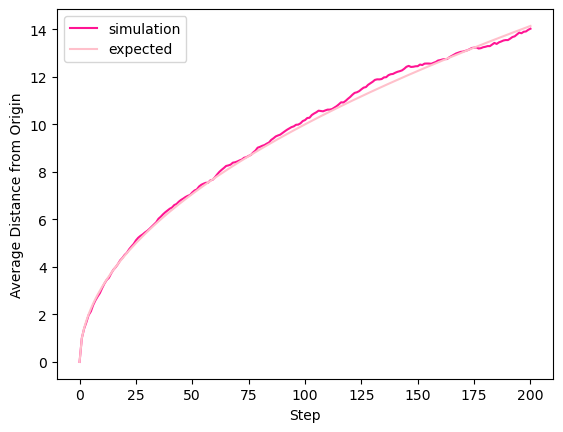

In [34]:
import numpy as np
import matplotlib.pyplot as plt

#1. setup parameters
n_walkers = 1000
n_steps = 200

#2. 2D array of steps
steps = np.random.choice([-1, 1], size=(n_walkers, n_steps+1)) # walkers-rows, steps-columns. +1 para tener una columna de posicion inicial
steps[:,0]=0 # hacemos 0 la primera columna

#3. actual walking distances (2D array "summing on each row")
positions = np.cumsum(steps, axis=1)

#4. square
squared_distances = positions**2 

# 5. mean
mean = np.mean(squared_distances, axis=0)

# 6. plot

plt.plot(np.sqrt(mean), color='deeppink', label='simulation')
plt.plot(np.sqrt( (np.arange(n_steps+1) )), color='pink', label='expected')
plt.xlabel("Step")
plt.ylabel("Average Distance from Origin")
plt.legend()
plt.show()

# remember that in a random walk, the variance is proportional to time.
# so yes, the result was as expected.

In [35]:
#prueba 
# np.random.randint(-1, 2, size=(10,2)) 

9\. Analyze a data file 
  * Download the population of hares, lynxes and carrots at the beginning of the last century.
    ```python
    ! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
    ```

  * Check the content by looking within the file
  * Load the data (use an appropriate numpy method) into a 2D array
  * Create arrays out of the columns, the arrays being (in order): *year*, *hares*, *lynxes*, *carrots* 
  * Plot the 3 populations over the years
  * Compute the main statistical properties of the dataset (mean, std, correlations, etc.)
  * Which species has the highest population each year?

Do you feel there is some evident correlation here? [Studies](https://www.enr.gov.nt.ca/en/services/lynx/lynx-snowshoe-hare-cycle) tend to believe so.

In [36]:
# Load the data
data = np.loadtxt('populations.txt')
data

array([[ 1900., 30000.,  4000., 48300.],
       [ 1901., 47200.,  6100., 48200.],
       [ 1902., 70200.,  9800., 41500.],
       [ 1903., 77400., 35200., 38200.],
       [ 1904., 36300., 59400., 40600.],
       [ 1905., 20600., 41700., 39800.],
       [ 1906., 18100., 19000., 38600.],
       [ 1907., 21400., 13000., 42300.],
       [ 1908., 22000.,  8300., 44500.],
       [ 1909., 25400.,  9100., 42100.],
       [ 1910., 27100.,  7400., 46000.],
       [ 1911., 40300.,  8000., 46800.],
       [ 1912., 57000., 12300., 43800.],
       [ 1913., 76600., 19500., 40900.],
       [ 1914., 52300., 45700., 39400.],
       [ 1915., 19500., 51100., 39000.],
       [ 1916., 11200., 29700., 36700.],
       [ 1917.,  7600., 15800., 41800.],
       [ 1918., 14600.,  9700., 43300.],
       [ 1919., 16200., 10100., 41300.],
       [ 1920., 24700.,  8600., 47300.]])

In [37]:
# Create arrays out of the columns
year, hares, lynxes, carrots = data.T

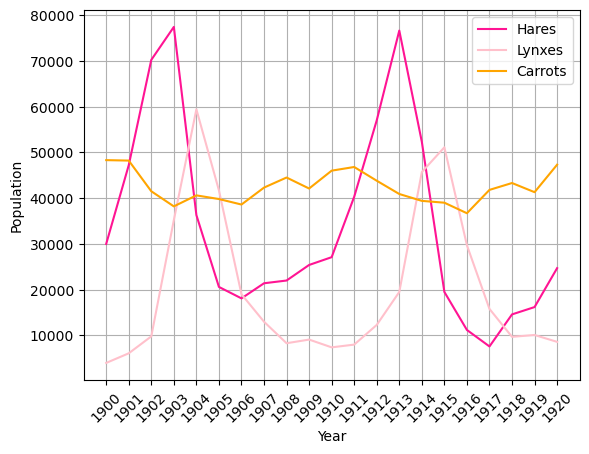

In [38]:
# Plot

plt.plot(year, hares, label='Hares', color='deeppink')
plt.plot(year, lynxes, label='Lynxes', color='pink')
plt.plot(year, carrots, label='Carrots', color='orange')

plt.xlabel("Year")
plt.ylabel("Population")
plt.xticks(year.astype(int), rotation=45)
plt.legend()
plt.grid()
plt.show()

In [39]:
# Compute the main statistical properties of the dataset (mean, std, correlations, etc.)

species_data = data[:,1:] # todas las filas y columnas desde la 1, omite la 0.
means = np.mean(species_data, axis=0)
stds = np.std(species_data, axis=0)
correlations = np.corrcoef(species_data, rowvar=False) # las variables estan en columnas

print(means)
print(stds)
print(correlations)

[34080.95238095 20166.66666667 42400.        ]
[20897.90645809 16254.59153691  3322.50622558]
[[ 1.          0.07189206 -0.01660378]
 [ 0.07189206  1.         -0.68057717]
 [-0.01660378 -0.68057717  1.        ]]


In [40]:
# Which species has the highest population each year?

species_names = np.array(['Hare', 'Lynx', 'Carrot'])
max_idx = np.argmax(species_data, axis=1)

print("Highest population per year:")
for y,idx in zip(year,max_idx):
    print(f'{int(y)}: {species_names[idx]}')

Highest population per year:
1900: Carrot
1901: Carrot
1902: Hare
1903: Hare
1904: Lynx
1905: Lynx
1906: Carrot
1907: Carrot
1908: Carrot
1909: Carrot
1910: Carrot
1911: Carrot
1912: Hare
1913: Hare
1914: Hare
1915: Lynx
1916: Carrot
1917: Carrot
1918: Carrot
1919: Carrot
1920: Carrot
